# XGBOOST — Predikcia priemyselnej produkcie SR

In [38]:
# import potrebnych kniznic a konfiguracia notebooku

import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from xgboost import XGBRegressor
import shap

import functions
importlib.reload(functions)
from functions import make_features, rolling_forecast_xgb, extract_tree_structure, trace_path_for_observation
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


print("Importy uspesne.")


Importy uspesne.


In [25]:
#data
DATA_PATH  = r"C:\Users\adamv\Desktop\ADAM\VS\Diplomovka\excel\data_mod.csv"
SHEET_NAME = "all"
TEST_SIZE = 24
N_LAGS = 3
RANDOM_STATE = 24
df_raw = pd.read_csv(DATA_PATH)
df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")
df = df_raw.copy()

In [26]:
#definovanie features, train/test vzorka
target = "pp_sa"
exog_cols = ["export_celkovy_sa", "trzby_priemysel_sa", "cpi", "crisis_dummy", "kurz_usd_eur"]
features = make_features(data = df, target = target, exog_cols= exog_cols, n_lags = 1)
X = features.drop(columns = [target])
y = features[target]
X = X.drop(columns=["trzby_priemysel_sa"])
X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

In [59]:
#tuning hyperparametrov
tscv = TimeSeriesSplit(n_splits=5)

#random_search
random_param_space = {
    "n_estimators": [100, 200, 300, 400, 600],
    "max_depth": [1, 2, 3, 4, 5, 6],
    "learning_rate": [0.05,0.01, 0.02, 0.05, 0.08, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 1.5, 2],
    "gamma": [0, 0.1, 0.5, 1, 5],
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE),
    param_distributions=random_param_space,
    n_iter=60,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

random_search.fit(X_train, y_train)
print("Najlepsie parametre z Random Search:", random_search.best_params_)

best = random_search.best_params_

#grid_search
grid_param_space = {
    "n_estimators": sorted(set([max(50, best["n_estimators"] - 100), best["n_estimators"], best["n_estimators"] + 100])),
    "max_depth": sorted(set([max(1, best["max_depth"] - 1), best["max_depth"], best["max_depth"] + 1])),
    "learning_rate": sorted(set([round(best["learning_rate"] * 0.5, 4), best["learning_rate"], round(best["learning_rate"] * 1.5, 4)])),
    "subsample": [best["subsample"]],
    "colsample_bytree": [best["colsample_bytree"]],
    "min_child_weight": [best["min_child_weight"]],
    "reg_alpha": [best["reg_alpha"]],
    "reg_lambda": [best["reg_lambda"]],
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE),
    param_grid=grid_param_space,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("Finalne parametre po Grid Search:", best_params)

Najlepsie parametre z Random Search: {'subsample': 0.6, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 100, 'min_child_weight': 7, 'max_depth': 1, 'learning_rate': 0.05, 'gamma': 5, 'colsample_bytree': 0.6}
Finalne parametre po Grid Search: {'colsample_bytree': 0.6, 'learning_rate': 0.025, 'max_depth': 1, 'min_child_weight': 7, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 2, 'subsample': 0.6}


In [ ]:
#porovnanie priemerného CV RMSE pre max_depth=1 vs. max_depth=2
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results[["param_max_depth", "mean_test_score", "std_test_score"]].sort_values("param_max_depth")

,param_max_depth,mean_test_score,std_test_score
0,1,-3.737602,1.207616
1,1,-3.688947,1.230738
2,1,-3.665731,1.203610
7,1,-3.678620,1.203029
6,1,-3.710546,1.231200
13,1,-3.707576,1.178703
14,1,-3.766881,1.113605
8,1,-3.715439,1.135125
12,1,-3.717173,1.203887
4,2,-3.682287,1.209384


In [60]:
#trenovanie a rmse modelu
init_train_size = len(y) - TEST_SIZE
results, last_model = rolling_forecast_xgb(X, y, initial_train_size = init_train_size, refit_every= N_LAGS, objective =  "reg:squarederror", xgb_params=best_params)
rmse = np.sqrt(mean_squared_error(results["actual"], results["predicted"]))
print(f"XGBoost rolling forecast RMSE: {rmse:.4f}")

XGBoost rolling forecast RMSE: 2.4792


In [61]:
#shap
explainer = shap.TreeExplainer(last_model)
shap_values = explainer.shap_values(X_test)
shap_summary = pd.DataFrame(shap_values, columns = X_test.columns, index = X_test.index)
mean_abs_shap = np.abs(shap_summary).mean().sort_values(ascending=False)
mean_abs_shap

export_celkovy_sa          1.016280
pp_sa_lag1                 0.236812
cpi                        0.116510
export_celkovy_sa_lag1     0.113135
kurz_usd_eur               0.059786
cpi_lag1                   0.054378
trzby_priemysel_sa_lag1    0.036006
month                      0.027533
trend                      0.025552
kurz_usd_eur_lag1          0.014230
quarter                    0.009876
crisis_dummy               0.000000
crisis_dummy_lag1          0.000000
dtype: float32

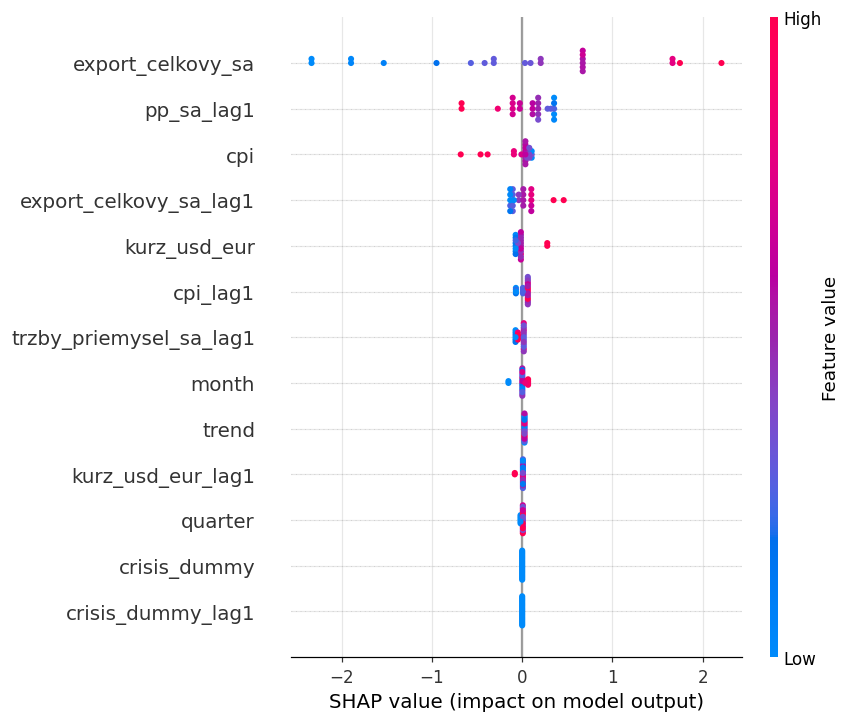

In [62]:
#graf ku shapu
shap.summary_plot(shap_values, X_test)

In [63]:
trees_df = extract_tree_structure(last_model)
trees_df

,Tree,Target,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
0,0,0,0,0-0,export_celkovy_sa,84.1544,0-1,0-2,0-2,283.40216,172.0,None
1,0,0,1,0-1,Leaf,<NA>,<NA>,<NA>,<NA>,-0.024002,107.0,None
2,0,0,2,0-2,Leaf,<NA>,<NA>,<NA>,<NA>,0.041326,65.0,None
3,1,0,0,1-0,export_celkovy_sa,-54.0975,1-1,1-2,1-2,318.602,172.0,None
4,1,0,1,1-1,Leaf,<NA>,<NA>,<NA>,<NA>,-0.052198,49.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...
595,198,0,1,198-1,Leaf,<NA>,<NA>,<NA>,<NA>,0.032368,51.0,None
596,198,0,2,198-2,Leaf,<NA>,<NA>,<NA>,<NA>,-0.001941,133.0,None
597,199,0,0,199-0,export_celkovy_sa,-305.0489,199-1,199-2,199-2,115.70419,184.0,None
598,199,0,1,199-1,Leaf,<NA>,<NA>,<NA>,<NA>,-0.087514,7.0,None


In [64]:
# iba listove uzly (vahy) jedneho konkretneho stromu
tree_0_leaves = trees_df[(trees_df["Tree"] == 0) & (trees_df["Feature"] == "Leaf")]
print(tree_0_leaves[["Tree", "Node", "Gain", "Cover"]])

   Tree  Node      Gain  Cover
1     0     1 -0.024002  107.0
2     0     2  0.041326   65.0


In [65]:
#najcastejsie pouzivane premenne na delenie
split_counts = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")
    .size()
    .sort_values(ascending=False)
)
print(split_counts)

Feature
export_celkovy_sa          94
pp_sa_lag1                 31
cpi                        16
export_celkovy_sa_lag1     15
kurz_usd_eur               12
kurz_usd_eur_lag1           9
trzby_priemysel_sa_lag1     6
trend                       6
cpi_lag1                    5
month                       5
quarter                     1
dtype: int64


In [66]:
#priemerny Gain pri deleni podla premennej
avg_gain_by_feature = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")["Gain"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_gain_by_feature)

Feature
export_celkovy_sa          167.294205
pp_sa_lag1                  98.895413
kurz_usd_eur_lag1           80.852602
cpi                         78.155176
month                       60.874557
kurz_usd_eur                60.252626
export_celkovy_sa_lag1      58.530043
cpi_lag1                    56.269431
trzby_priemysel_sa_lag1     51.843223
trend                       50.974432
quarter                      42.59849
Name: Gain, dtype: Float64


In [67]:
#kompletna struktura jedneho konkretneho stromu
tree_0_full = trace_path_for_observation(trees_df, tree_index=99)
print(tree_0_full)

     Node     Feature     Split   Yes    No      Gain  Cover
297     0  pp_sa_lag1  2.184827  99-1  99-2  89.26537  187.0
298     1        Leaf      <NA>  <NA>  <NA>  0.016646  149.0
299     2        Leaf      <NA>  <NA>  <NA> -0.025256   38.0


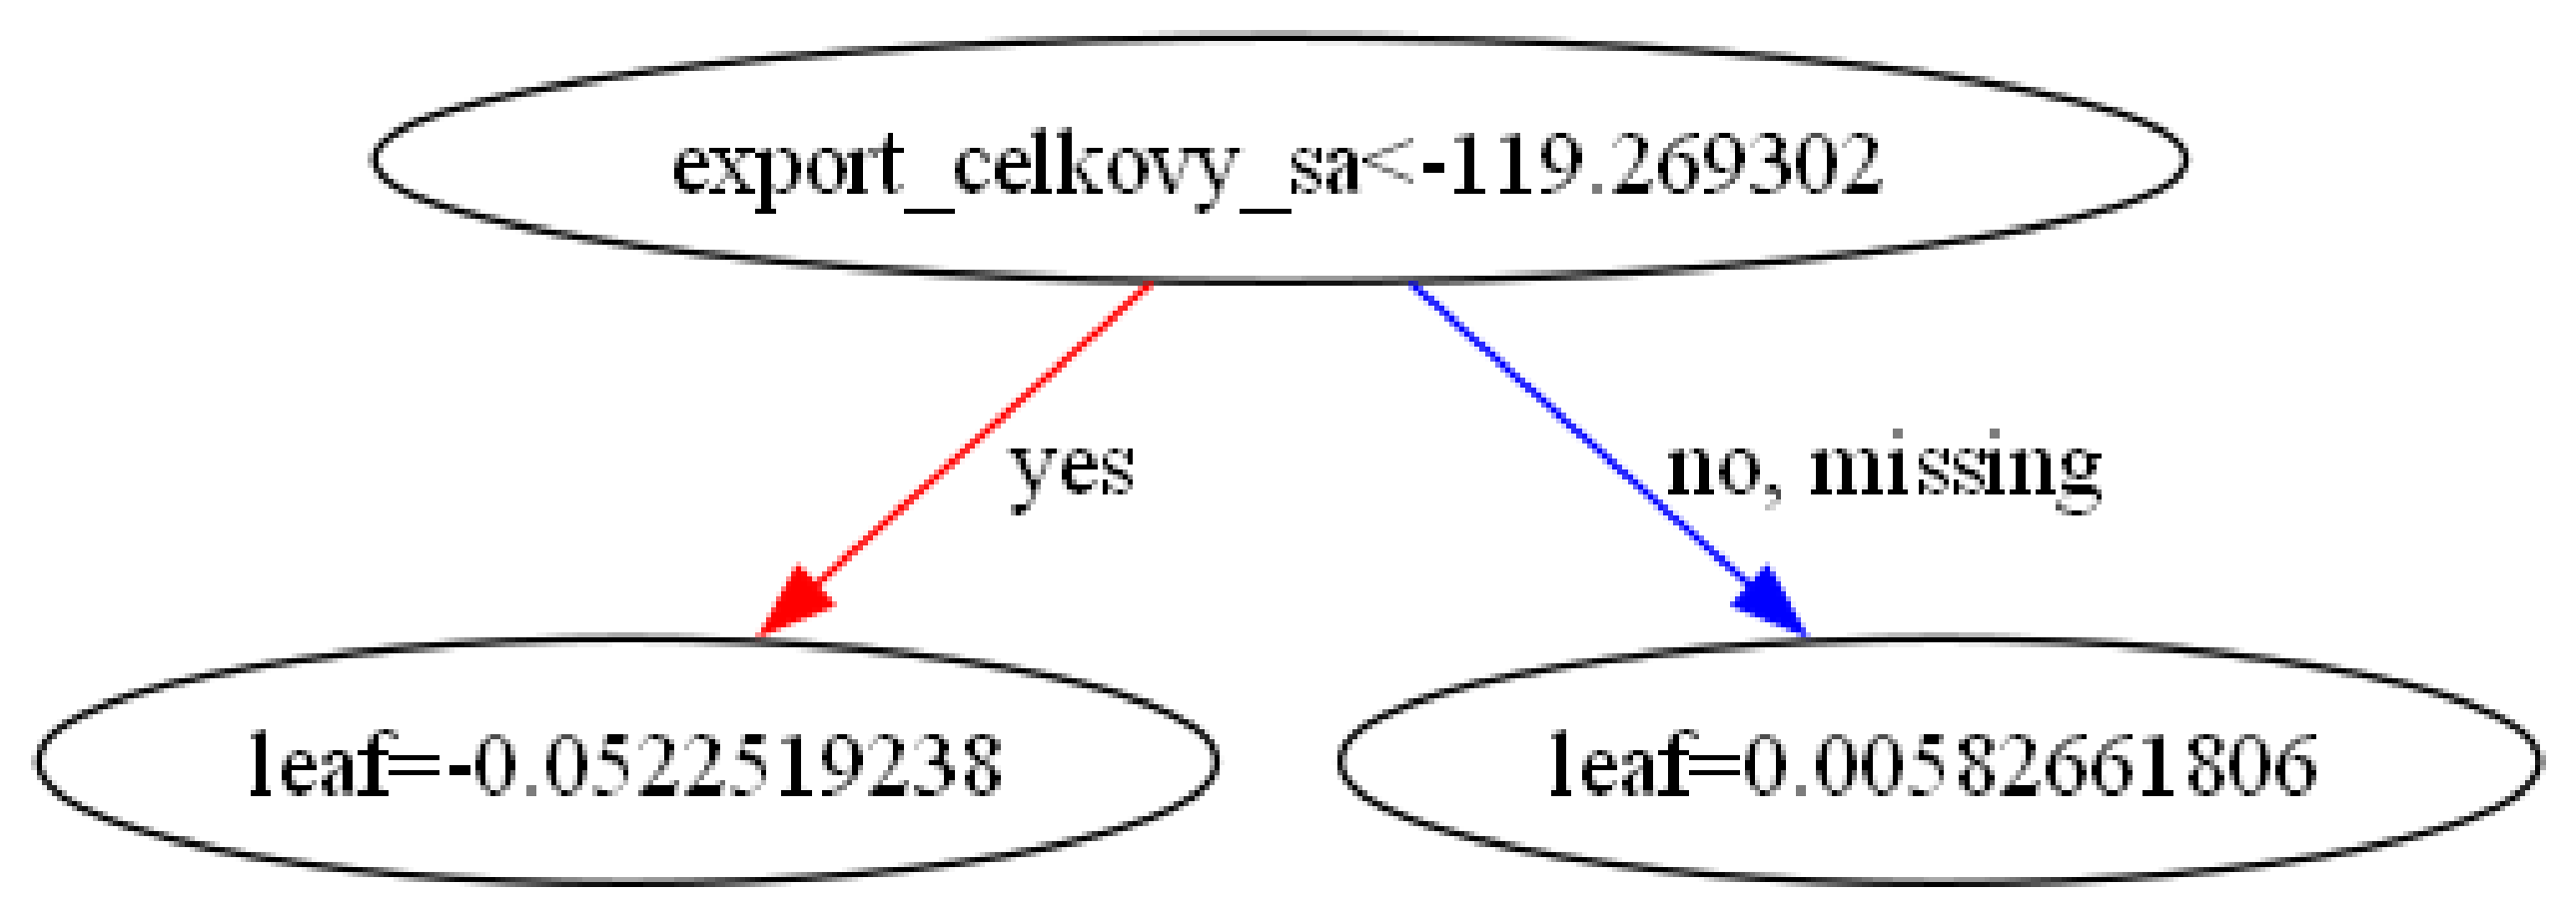

In [68]:
#graficke zobrazenie stromu
from xgboost import plot_tree
import matplotlib.pyplot as plt

plot_tree(last_model, num_trees=100)
fig = plt.gcf()
fig.set_size_inches(30, 15)

In [69]:
#Pocet listov a vnutornych uzlov pre kazdy strom
tree_summary = trees_df.groupby("Tree").agg(
    n_nodes=("Node", "count"),
    n_leaves=("Feature", lambda x: (x == "Leaf").sum()),
).reset_index()

# pre binarny strom: n_splits = n_leaves - 1
tree_summary["n_splits"] = tree_summary["n_leaves"] - 1

In [70]:
#Zakladna statistika - kolko stromov ma 0, 1, 2+ deleni
split_distribution = tree_summary["n_splits"].value_counts().sort_index()
print("Rozdelenie poctu deleni naprieč stromami:")
print(split_distribution)

n_trivial = (tree_summary["n_splits"] == 0).sum()
n_single_split = (tree_summary["n_splits"] == 1).sum()
n_multi_split = (tree_summary["n_splits"] > 1).sum()

print(f"\nStromy bez delenia (len 1 list):       {n_trivial}")
print(f"Stromy s presne 1 delenim (2 listy):    {n_single_split}")
print(f"Stromy s viac ako 1 delenim (3+ listy): {n_multi_split}")


Rozdelenie poctu deleni naprieč stromami:
n_splits
1    200
Name: count, dtype: int64

Stromy bez delenia (len 1 list):       0
Stromy s presne 1 delenim (2 listy):    200
Stromy s viac ako 1 delenim (3+ listy): 0


In [71]:
#ktore konkretne stromy maju viac ako 1 delenie
trees_with_multi_splits = tree_summary[tree_summary["n_splits"] > 1].sort_values(
    "n_splits", ascending=False
)
print("\nStromy s viac ako 1 delenim (zoradene podla poctu deleni):")
print(trees_with_multi_splits)


Stromy s viac ako 1 delenim (zoradene podla poctu deleni):
Empty DataFrame
Columns: [Tree, n_nodes, n_leaves, n_splits]
Index: []


In [72]:
# Priemerny pocet deleni cez cely ansambel - rychly diagnosticky ukazovatel
avg_splits = tree_summary["n_splits"].mean()
pct_trivial = (n_trivial / len(tree_summary)) * 100
print(f"\nPriemerny pocet deleni na strom: {avg_splits:.2f}")
print(f"Podiel trivialnych (nerozdelenych) stromov: {pct_trivial:.1f}%")


Priemerny pocet deleni na strom: 1.00
Podiel trivialnych (nerozdelenych) stromov: 0.0%
